<a href="https://colab.research.google.com/github/FelipeMoreira199825/FelipeMoreira199825/blob/main/teste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisando os dados do portal da transparência**

In [ ]:
ano = 2024
caminho_dados = "/content/drive/MyDrive/Analise_De_Dados/{ano}_Viagem.csv"
caminho_saida = "/content/drive/MyDrive/Analise_De_Dados/output/tabela_{ano}.xlsx"
caminho_figura = '/content/drive/MyDrive/Analise_De_Dados/output/figura_{ano}.png'

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:2f}'.format)

# Define o caminho do arquivo
caminho_dados = "/content/drive/MyDrive/Analise_De_Dados/2024_Viagem.csv"

# Lendo os dados
df_viagens = pd.read_csv(caminho_dados, encoding="Windows-1252", sep=";" , decimal=",")

#Criando nova coluna de despesas
df_viagens["Despesas"] = df_viagens["Valor diárias"] + df_viagens["Valor passagens"] + df_viagens["Valor outros gastos"]

# Ajustando valores nulos na coluna de cargo
df_viagens["Cargo"] = df_viagens["Cargo"].fillna("NÃO INFORMADO")

#Convertendo colunas de datas
df_viagens['Período - Data de início'] = pd.to_datetime(df_viagens['Período - Data de início'], format="%d/%m/%Y")
df_viagens['Período - Data de fim'] = pd.to_datetime(df_viagens['Período - Data de fim'], format="%d/%m/%Y")

#Criando novas colunas de datas
df_viagens["Mês da viagem"] = df_viagens["Período - Data de início"].dt.month_name()

df_viagens["Dias de viagem"] = (df_viagens["Período - Data de fim"] - df_viagens["Período - Data de início"]).dt.days




/tmp/ipython-input-48-1286996305.py:9: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_viagens = pd.read_csv(caminho_dados, encoding="Windows-1252", sep=";" , decimal=",")


In [ ]:
 #Criando tabela consolidada
 df_viagens_consolidado = (
  df_viagens
    .groupby("Cargo")
    .agg(
        despesas_media=("Despesas", "mean"),
        duracao_media=("Dias de viagem", "mean"),
        despesas_totais=("Despesas", "sum"),
        duracao_total=("Dias de viagem", "sum"),
        destino_mais_frequentes=("Destinos", pd.Series.mode),
        n_viagens=("Nome" , "count")
    )

        .reset_index()
        .sort_values(by="despesas_totais", ascending=False))

 #Filtrando tabela consolidada por cargos relevantes (>1% das viagens)
 df_cargos = df_viagens['Cargo'].value_counts(normalize=True).reset_index()
 cargos_relevantes = df_cargos.loc[df_cargos['proportion'] > 0.01, 'Cargo']
 filtro = df_viagens_consolidado['Cargo'].isin(cargos_relevantes)

 # Chegando na tabela final - consolidada e filtrada!
 df_final = df_viagens_consolidado[filtro].sort_values(by="n_viagens", ascending=False)

 #Salvando a tebela final
 df_final.to_excel(caminho_saida, index=False)

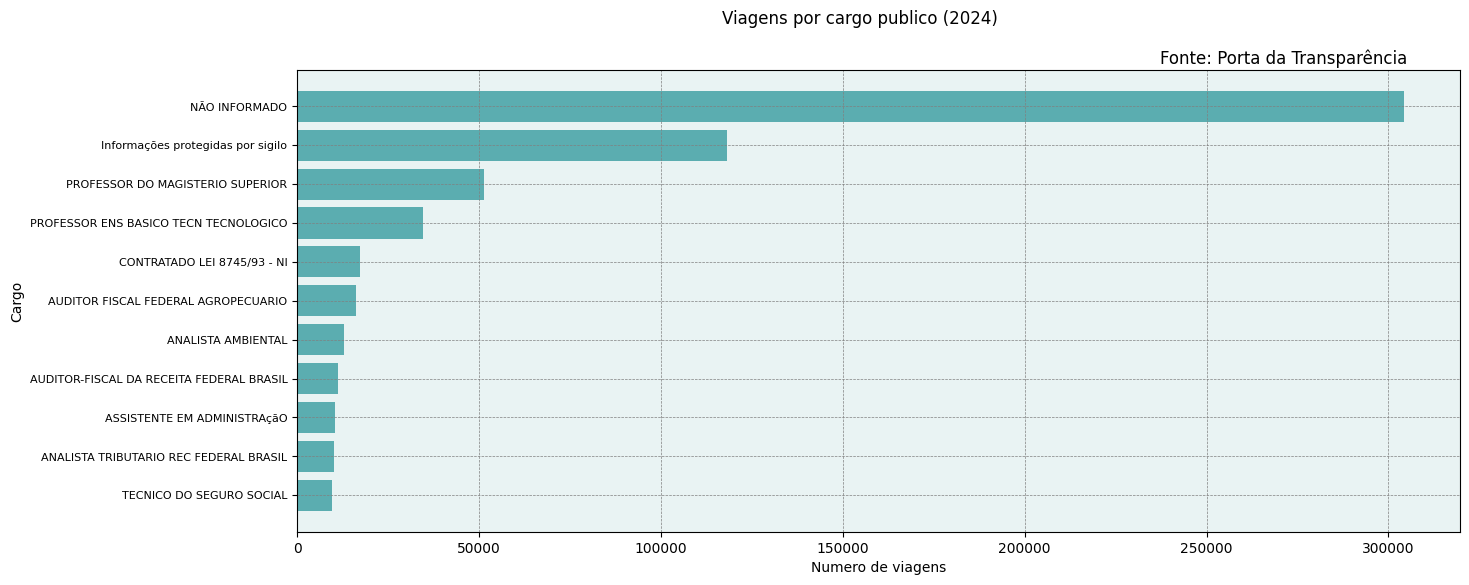

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 6))
#Cargos e cor das barras
ax.barh(df_final['Cargo'], df_final['n_viagens'], color='#5BADB0')
ax.invert_yaxis()
ax.set_ylabel('Cargo')
#Cor de fundo
ax.set_facecolor('#E9F3F3')



fig.suptitle('Viagens por cargo publico (2024)')
#Titulo e posição do texto
plt.figtext(0.70, 0.89, 'Fonte: Porta da Transparência', fontsize=12)

plt.grid(color = 'gray', linestyle= '--', linewidth=0.5)
plt.yticks(fontsize=8)

plt.xlabel('Numero de viagens')
#Salvando o grafico
plt.savefig(caminho_figura, bbox_inches='tight')

In [ ]:
df_final

,Cargo,despesas_media,duracao_media,despesas_totais,duracao_total,destino_mais_frequentes,n_viagens
521,NÃO INFORMADO,3579.283419,7.643197,1089344170.870000,2326184,BRASÍLIA/DF,304347
466,Informações protegidas por sigilo,3421.850087,7.409475,403894653.210000,874570,Informações protegidas por sigilo,118034
598,PROFESSOR DO MAGISTERIO SUPERIOR,2228.446684,3.873490,114531017.340000,199078,BRASÍLIA/DF,51395
599,PROFESSOR ENS BASICO TECN TECNOLOGICO,1524.213660,2.361030,52684445.160000,81609,BRASÍLIA/DF,34565
335,CONTRATADO LEI 8745/93 - NI,847.172019,2.262108,14570511.560000,38906,FORTALEZA/CE,17199
229,AUDITOR FISCAL FEDERAL AGROPECUARIO,1549.371663,2.064859,25082777.860000,33428,BRASÍLIA/DF,16189
91,ANALISTA AMBIENTAL,2818.692950,5.197634,36454155.920000,67221,BRASÍLIA/DF,12933
230,AUDITOR-FISCAL DA RECEITA FEDERAL BRASIL,2935.183894,3.142883,32847642.960000,35172,BRASÍLIA/DF,11191
199,ASSISTENTE EM ADMINISTRAçãO,1517.802198,2.258052,15880764.400000,23626,BRASÍLIA/DF,10463
133,ANALISTA TRIBUTARIO REC FEDERAL BRASIL,2053.417182,3.423526,20581400.420000,34314,BRASÍLIA/DF,10023


In [ ]:

df_viagens[["Valor diárias", "Valor passagens", "Valor outros gastos"]]

,Valor diárias,Valor passagens,Valor outros gastos
0,929.180000,0.000000,0.000000
1,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000
4,14176.380000,6892.310000,0.000000
...,...,...,...
787181,262.050000,0.000000,0.000000
787182,1204.090000,4044.690000,0.000000
787183,0.000000,0.000000,0.000000
787184,0.000000,5562.820000,0.000000


In [ ]:
# Removendo o espaço extra nos nomes das colunas
# Convertendo as colunas para string antes de aplicar .str para garantir que funcionem
df_viagens["Valor diárias"] = df_viagens["Valor diárias"].astype(str).str.replace(",", ".").astype(float)
df_viagens["Valor passagens"] = df_viagens["Valor passagens"].astype(str).str.replace(",", ".").astype(float)
df_viagens["Valor outros gastos"] = df_viagens["Valor outros gastos"].astype(str).str.replace(",", ".").astype(float)

In [ ]:
df_viagens["Valor diárias"] + df_viagens["Valor passagens"] + df_viagens["Valor outros gastos"]

,0
0,929.180000
1,0.000000
2,0.000000
3,0.000000
4,21068.690000
...,...
787181,262.050000
787182,5248.780000
787183,0.000000
787184,5562.820000


In [ ]:
df_viagens

,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Despesas,Mês da viagem,Dias de viagem
0,18831091,000011/24,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26425,"Instituto Federal de Educação, Ciência e Tecno...",***.405.257-**,RICARDO DOS SANTOS PEREIRA,PROFESSOR ENS BASICO TECN TECNOLOGICO,-1,Sem informação,2024-02-23,2024-02-25,Rio Branco/AC,Ministrar a disciplina de Conceitos e Aplicaçõ...,929.180000,0.000000,0.000000,0.000000,929.180000,February,2
1,18831495,000001/24,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26274,Fundação Universidade Federal de Uberlândia,***.587.016-**,LETICIA SANCHEZ FERREIRA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2024-01-18,2024-01-22,SÃO PAULO/SP,Participação nas atividades do ESTAGIO DE CAPA...,0.000000,0.000000,0.000000,0.000000,0.000000,January,4
2,18831777,000002/24,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26274,Fundação Universidade Federal de Uberlândia,***.587.016-**,LETICIA SANCHEZ FERREIRA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2024-02-29,2024-03-04,SÃO PAULO/SP,Participação nas atividades do ESTAGIO DE CAPA...,0.000000,0.000000,0.000000,0.000000,0.000000,February,4
3,18831821,000003/24,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26274,Fundação Universidade Federal de Uberlândia,***.587.016-**,LETICIA SANCHEZ FERREIRA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2024-04-11,2024-04-15,SÃO PAULO/SP,Participação nas atividades do ESTAGIO DE CAPA...,0.000000,0.000000,0.000000,0.000000,0.000000,April,4
4,19177818,000001/24-1C,Realizada,SIM,Inclusão das diárias.,26000,Ministério da Educação,26271,Fundação Universidade de Brasília,***.626.601-**,VIRGINIA MARIA VASCONCELOS LEAL,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2024-01-29,2024-02-06,"Lille/França, PARIS/FRANÇA",Programação dos eventos que a Professora irá p...,14176.380000,6892.310000,0.000000,0.000000,21068.690000,January,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787181,2024001911,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.902.438-**,NAGEL LISANIAS PAULINO,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2024-12-16,2024-12-16,Sem informação,"Participar, como palestrante, no evento '1 ano...",262.050000,0.000000,0.000000,0.000000,262.050000,December,0
787182,2024001912,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.697.505-**,EDSON BROXADO DE FRANCA TEIXEIRA,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2024-12-17,2024-12-18,Sem informação,Assessorar o Diretor de Fiscalização e cumprir...,1204.090000,4044.690000,0.000000,0.000000,5248.780000,December,1
787183,2024001938,Sem informaçã,Não realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.827.438-**,GABRIEL MURICCA GALIPOLO,DIRETOR DO BANCO CENTRAL,-1,Sem informação,2024-12-26,2024-12-27,Sem informação,Cumprir agenda em Brasília.,0.000000,0.000000,0.000000,0.000000,0.000000,December,1
787184,2024001946,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.425.230-**,GILNEU FRANCISCO ASTOLFI VIVAN,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2024-12-29,2024-12-31,Sem informação,Suspensão das férias do servidor por motivo de...,0.000000,5562.820000,0.000000,0.000000,5562.820000,December,2


In [ ]:
df_viagens["Despesas"] = df_viagens["Valor diárias"] + df_viagens["Valor passagens"] + df_viagens["Valor outros gastos"]

In [ ]:
(df_viagens["Cargo"].value_counts(normalize=True) *100) . rename('VIAGENS POR CARGO') . reset_index()

,Cargo,VIAGENS POR CARGO
0,NÃO INFORMADO,38.662654
1,Informações protegidas por sigilo,14.994423
2,PROFESSOR DO MAGISTERIO SUPERIOR,6.528952
3,PROFESSOR ENS BASICO TECN TECNOLOGICO,4.390957
4,CONTRATADO LEI 8745/93 - NI,2.184871
...,...,...
849,PROGRAMADOR EDUCACIONAL - NS,0.000127
850,GUARDA DE PRESIDIO CIVIL TERCEIRA,0.000127
851,ANALISTA I - 40HORAS,0.000127
852,MEDICO II - 36HORAS,0.000127


In [ ]:
df_viagens["Cargo"]

,Cargo
0,PROFESSOR ENS BASICO TECN TECNOLOGICO
1,PROFESSOR DO MAGISTERIO SUPERIOR
2,PROFESSOR DO MAGISTERIO SUPERIOR
3,PROFESSOR DO MAGISTERIO SUPERIOR
4,PROFESSOR DO MAGISTERIO SUPERIOR
...,...
787181,ANALISTA DO BANCO CENTRAL
787182,ANALISTA DO BANCO CENTRAL
787183,DIRETOR DO BANCO CENTRAL
787184,ANALISTA DO BANCO CENTRAL


In [ ]:
gastos_totais_por_cargo = df_viagens.groupby("Cargo")["Despesas"].sum().reset_index()

In [ ]:
gastos_totais_por_cargo[gastos_totais_por_cargo["Despesas"]> 10000000 ]

,Cargo,Despesas
19,AGENTE ADMINISTRATIVO,14886937.610000
91,ANALISTA AMBIENTAL,36454155.920000
115,ANALISTA DO SEGURO SOCIAL,13025256.220000
133,ANALISTA TRIBUTARIO REC FEDERAL BRASIL,20581400.420000
199,ASSISTENTE EM ADMINISTRAçãO,15880764.400000
229,AUDITOR FISCAL FEDERAL AGROPECUARIO,25082777.860000
230,AUDITOR-FISCAL DA RECEITA FEDERAL BRASIL,32847642.960000
335,CONTRATADO LEI 8745/93 - NI,14570511.560000
409,ESP EM REGULACAO DE AVIACAO CIVIL,12716610.290000
412,ESP EM REGULACAO E VIGILANCIA SANITARIA,27134093.590000


In [ ]:
df_viagens


,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Despesas,Mês da viagem,Dias de viagem
0,18831091,000011/24,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26425,"Instituto Federal de Educação, Ciência e Tecno...",***.405.257-**,RICARDO DOS SANTOS PEREIRA,PROFESSOR ENS BASICO TECN TECNOLOGICO,-1,Sem informação,2024-02-23,2024-02-25,Rio Branco/AC,Ministrar a disciplina de Conceitos e Aplicaçõ...,929.180000,0.000000,0.000000,0.000000,929.180000,February,2
1,18831495,000001/24,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26274,Fundação Universidade Federal de Uberlândia,***.587.016-**,LETICIA SANCHEZ FERREIRA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2024-01-18,2024-01-22,SÃO PAULO/SP,Participação nas atividades do ESTAGIO DE CAPA...,0.000000,0.000000,0.000000,0.000000,0.000000,January,4
2,18831777,000002/24,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26274,Fundação Universidade Federal de Uberlândia,***.587.016-**,LETICIA SANCHEZ FERREIRA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2024-02-29,2024-03-04,SÃO PAULO/SP,Participação nas atividades do ESTAGIO DE CAPA...,0.000000,0.000000,0.000000,0.000000,0.000000,February,4
3,18831821,000003/24,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26274,Fundação Universidade Federal de Uberlândia,***.587.016-**,LETICIA SANCHEZ FERREIRA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2024-04-11,2024-04-15,SÃO PAULO/SP,Participação nas atividades do ESTAGIO DE CAPA...,0.000000,0.000000,0.000000,0.000000,0.000000,April,4
4,19177818,000001/24-1C,Realizada,SIM,Inclusão das diárias.,26000,Ministério da Educação,26271,Fundação Universidade de Brasília,***.626.601-**,VIRGINIA MARIA VASCONCELOS LEAL,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2024-01-29,2024-02-06,"Lille/França, PARIS/FRANÇA",Programação dos eventos que a Professora irá p...,14176.380000,6892.310000,0.000000,0.000000,21068.690000,January,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787181,2024001911,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.902.438-**,NAGEL LISANIAS PAULINO,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2024-12-16,2024-12-16,Sem informação,"Participar, como palestrante, no evento '1 ano...",262.050000,0.000000,0.000000,0.000000,262.050000,December,0
787182,2024001912,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.697.505-**,EDSON BROXADO DE FRANCA TEIXEIRA,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2024-12-17,2024-12-18,Sem informação,Assessorar o Diretor de Fiscalização e cumprir...,1204.090000,4044.690000,0.000000,0.000000,5248.780000,December,1
787183,2024001938,Sem informaçã,Não realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.827.438-**,GABRIEL MURICCA GALIPOLO,DIRETOR DO BANCO CENTRAL,-1,Sem informação,2024-12-26,2024-12-27,Sem informação,Cumprir agenda em Brasília.,0.000000,0.000000,0.000000,0.000000,0.000000,December,1
787184,2024001946,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.425.230-**,GILNEU FRANCISCO ASTOLFI VIVAN,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2024-12-29,2024-12-31,Sem informação,Suspensão das férias do servidor por motivo de...,0.000000,5562.820000,0.000000,0.000000,5562.820000,December,2


#trabalhando com datas

In [ ]:
pd.to_datetime(df_viagens['Período - Data de início'], format="%d/%m/%Y")

,Período - Data de início
0,2024-02-23
1,2024-01-18
2,2024-02-29
3,2024-04-11
4,2024-01-29
...,...
787181,2024-12-16
787182,2024-12-17
787183,2024-12-26
787184,2024-12-29


In [ ]:
df_viagens['Período - Data de início'] = pd.to_datetime(df_viagens['Período - Data de início'], format="%d/%m/%Y")
df_viagens['Período - Data de fim'] = pd.to_datetime(df_viagens['Período - Data de fim'], format="%d/%m/%Y")

In [ ]:
df_viagens

,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Despesas,Mês da viagem,Dias de viagem
0,18831091,000011/24,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26425,"Instituto Federal de Educação, Ciência e Tecno...",***.405.257-**,RICARDO DOS SANTOS PEREIRA,PROFESSOR ENS BASICO TECN TECNOLOGICO,-1,Sem informação,2024-02-23,2024-02-25,Rio Branco/AC,Ministrar a disciplina de Conceitos e Aplicaçõ...,929.180000,0.000000,0.000000,0.000000,929.180000,February,2
1,18831495,000001/24,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26274,Fundação Universidade Federal de Uberlândia,***.587.016-**,LETICIA SANCHEZ FERREIRA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2024-01-18,2024-01-22,SÃO PAULO/SP,Participação nas atividades do ESTAGIO DE CAPA...,0.000000,0.000000,0.000000,0.000000,0.000000,January,4
2,18831777,000002/24,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26274,Fundação Universidade Federal de Uberlândia,***.587.016-**,LETICIA SANCHEZ FERREIRA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2024-02-29,2024-03-04,SÃO PAULO/SP,Participação nas atividades do ESTAGIO DE CAPA...,0.000000,0.000000,0.000000,0.000000,0.000000,February,4
3,18831821,000003/24,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26274,Fundação Universidade Federal de Uberlândia,***.587.016-**,LETICIA SANCHEZ FERREIRA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2024-04-11,2024-04-15,SÃO PAULO/SP,Participação nas atividades do ESTAGIO DE CAPA...,0.000000,0.000000,0.000000,0.000000,0.000000,April,4
4,19177818,000001/24-1C,Realizada,SIM,Inclusão das diárias.,26000,Ministério da Educação,26271,Fundação Universidade de Brasília,***.626.601-**,VIRGINIA MARIA VASCONCELOS LEAL,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2024-01-29,2024-02-06,"Lille/França, PARIS/FRANÇA",Programação dos eventos que a Professora irá p...,14176.380000,6892.310000,0.000000,0.000000,21068.690000,January,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787181,2024001911,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.902.438-**,NAGEL LISANIAS PAULINO,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2024-12-16,2024-12-16,Sem informação,"Participar, como palestrante, no evento '1 ano...",262.050000,0.000000,0.000000,0.000000,262.050000,December,0
787182,2024001912,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.697.505-**,EDSON BROXADO DE FRANCA TEIXEIRA,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2024-12-17,2024-12-18,Sem informação,Assessorar o Diretor de Fiscalização e cumprir...,1204.090000,4044.690000,0.000000,0.000000,5248.780000,December,1
787183,2024001938,Sem informaçã,Não realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.827.438-**,GABRIEL MURICCA GALIPOLO,DIRETOR DO BANCO CENTRAL,-1,Sem informação,2024-12-26,2024-12-27,Sem informação,Cumprir agenda em Brasília.,0.000000,0.000000,0.000000,0.000000,0.000000,December,1
787184,2024001946,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.425.230-**,GILNEU FRANCISCO ASTOLFI VIVAN,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2024-12-29,2024-12-31,Sem informação,Suspensão das férias do servidor por motivo de...,0.000000,5562.820000,0.000000,0.000000,5562.820000,December,2


# Quantidades de dias que duraram cada viagem.

In [ ]:
df_viagens["Mês da viagem"] = df_viagens["Período - Data de início"].dt.month_name()

df_viagens["Dias de viagem"] = (df_viagens["Período - Data de fim"] - df_viagens["Período - Data de início"]).dt.days

In [ ]:
df_viagens

,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Despesas,Mês da viagem,Dias de viagem
0,18831091,000011/24,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26425,"Instituto Federal de Educação, Ciência e Tecno...",***.405.257-**,RICARDO DOS SANTOS PEREIRA,PROFESSOR ENS BASICO TECN TECNOLOGICO,-1,Sem informação,2024-02-23,2024-02-25,Rio Branco/AC,Ministrar a disciplina de Conceitos e Aplicaçõ...,929.180000,0.000000,0.000000,0.000000,929.180000,February,2
1,18831495,000001/24,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26274,Fundação Universidade Federal de Uberlândia,***.587.016-**,LETICIA SANCHEZ FERREIRA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2024-01-18,2024-01-22,SÃO PAULO/SP,Participação nas atividades do ESTAGIO DE CAPA...,0.000000,0.000000,0.000000,0.000000,0.000000,January,4
2,18831777,000002/24,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26274,Fundação Universidade Federal de Uberlândia,***.587.016-**,LETICIA SANCHEZ FERREIRA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2024-02-29,2024-03-04,SÃO PAULO/SP,Participação nas atividades do ESTAGIO DE CAPA...,0.000000,0.000000,0.000000,0.000000,0.000000,February,4
3,18831821,000003/24,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26274,Fundação Universidade Federal de Uberlândia,***.587.016-**,LETICIA SANCHEZ FERREIRA,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2024-04-11,2024-04-15,SÃO PAULO/SP,Participação nas atividades do ESTAGIO DE CAPA...,0.000000,0.000000,0.000000,0.000000,0.000000,April,4
4,19177818,000001/24-1C,Realizada,SIM,Inclusão das diárias.,26000,Ministério da Educação,26271,Fundação Universidade de Brasília,***.626.601-**,VIRGINIA MARIA VASCONCELOS LEAL,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2024-01-29,2024-02-06,"Lille/França, PARIS/FRANÇA",Programação dos eventos que a Professora irá p...,14176.380000,6892.310000,0.000000,0.000000,21068.690000,January,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787181,2024001911,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.902.438-**,NAGEL LISANIAS PAULINO,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2024-12-16,2024-12-16,Sem informação,"Participar, como palestrante, no evento '1 ano...",262.050000,0.000000,0.000000,0.000000,262.050000,December,0
787182,2024001912,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.697.505-**,EDSON BROXADO DE FRANCA TEIXEIRA,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2024-12-17,2024-12-18,Sem informação,Assessorar o Diretor de Fiscalização e cumprir...,1204.090000,4044.690000,0.000000,0.000000,5248.780000,December,1
787183,2024001938,Sem informaçã,Não realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.827.438-**,GABRIEL MURICCA GALIPOLO,DIRETOR DO BANCO CENTRAL,-1,Sem informação,2024-12-26,2024-12-27,Sem informação,Cumprir agenda em Brasília.,0.000000,0.000000,0.000000,0.000000,0.000000,December,1
787184,2024001946,Sem informaçã,Realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.425.230-**,GILNEU FRANCISCO ASTOLFI VIVAN,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2024-12-29,2024-12-31,Sem informação,Suspensão das férias do servidor por motivo de...,0.000000,5562.820000,0.000000,0.000000,5562.820000,December,2


#Excluindo coluna

In [ ]:
df_viagens.drop(columns=["Dias da viagem"], inplace=True)


KeyError: "['Dias da viagem'] not found in axis"

In [ ]:
df_viagens

In [ ]:
 (
  df_viagens
    .groupby("Cargo")
    .agg(
        despesas_media=("Despesas", "mean"),
        duracao_media=("Dias de viagem", "mean"),
        despesas_totais=("Despesas", "sum"),
        duracao_total=("Dias de viagem", "sum"),
        destino_mais_frequentes=("Destinos", pd.Series.mode),
        n_viagens=("Nome" , "count")
    )

        .reset_index()
)

In [ ]:
 df_cargos = df_viagens['Cargo'].value_counts(normalize=True).reset_index()
 df_cargos


In [ ]:
df_cargos.loc[df_cargos['proportion'] > 0.01, 'Cargo']

In [ ]:
 df_viagens_consolidado = (
  df_viagens
    .groupby("Cargo")
    .agg(
        despesas_media=("Despesas", "mean"),
        duracao_media=("Dias de viagem", "mean"),
        despesas_totais=("Despesas", "sum"),
        duracao_total=("Dias de viagem", "sum"),
        destino_mais_frequentes=("Destinos", pd.Series.mode),
        n_viagens=("Nome" , "count")
    )

        .reset_index()
)

In [ ]:
cargos_relevantes = df_cargos.loc[df_cargos['proportion'] > 0.01, 'Cargo']

In [ ]:
filtro = df_viagens_consolidado['Cargo'].isin(cargos_relevantes)

In [ ]:
df_final = df_viagens_consolidado[filtro]

In [ ]:
df_cargos

#Criando tabela

In [ ]:
df_final = df_final.sort_values(by="n_viagens", ascending=False)

In [ ]:
df_final.plot(x="Cargo", y="n_viagens", kind="bar")

#Importando matplotlib para trabalhar melhir com graficos

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
#Cargos e cor das barras
ax.barh(df_final['Cargo'], df_final['n_viagens'], color='#5BADB0')
ax.invert_yaxis()
ax.set_ylabel('Cargo')
#Cor de fundo
ax.set_facecolor('#E9F3F3')



fig.suptitle('Viagens por cargo publico (2024)')
#Titulo e posição do texto
plt.figtext(0.70, 0.89, 'Fonte: Porta da Transparência', fontsize=12)

plt.grid(color = 'gray', linestyle= '--', linewidth=0.5)
plt.yticks(fontsize=8)

plt.xlabel('Numero de viagens')

plt.show()

In [ ]:
df_viagens


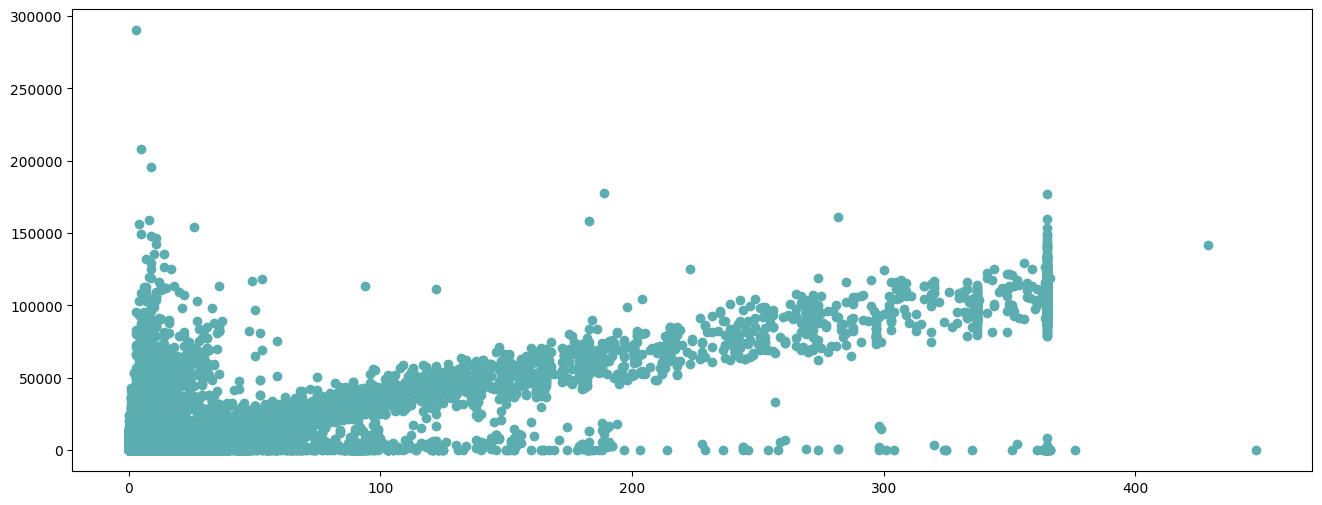

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.scatter(df_viagens['Dias de viagem'], df_viagens['Despesas'], color='#5BADB0')
#ax.set_xlabel('Dias de viagem')
#ax.set_ylabel('Despesas')
#ax.set_facecolor('#E9F3F3')

#VERIFICANDO QUAIS VIAGENS GASTARAM MAIS


In [ ]:
(df_viagens['Despesas'] > 200_000).value_counts()

,count
Despesas,
False,787184
True,2


In [ ]:
filtro = df_viagens['Despesas'] > 200_000
df_viagens[filtro]

,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Despesas,Mês da viagem,Dias de viagem
263424,19989596,014282/24,Não realizada,NÃO,Sem informação,-1,Sem informação,-1,Sem informação,***.639.875-**,OLGA MARIA SILVA EMBIRUCU,AUDITOR-FISCAL DA RECEITA FEDERAL BRASIL,-1,Sem informação,2024-06-12,2024-06-15,RIO DE JANEIRO/RJ,Foco na identificação das soluções tecnológica...,0.000000,290096.160000,0.000000,0.000000,290096.160000,June,3
358970,20109417,001426/24-2C,Realizada,SIM,Ajuste de dados.,20000,Presidência da República,20000,Presidência da República - Unidades com víncul...,***.050.944-**,CELSO LUIZ NUNES AMORIM,NÃO INFORMADO,CCX-0118,CCX-0118,2024-07-16,2024-07-21,WASHINGTON/ESTADOS UNIDOS DA AMÉRICA,Encontro com autoridades dos Estados Unidos da...,7675.590000,199689.550000,0.000000,532.330000,207897.470000,July,5


In [ ]:
caminho_dados_passagens ="/content/drive/MyDrive/Analise_De_Dados/2024_Passagem.csv"
df_passagens = pd.read_csv(caminho_dados_passagens, encoding="Windows-1252", sep=";" , decimal=",")
df_passagens

,Identificador do processo de viagem,Número da Proposta (PCDP),Meio de transporte,País - Origem ida,UF - Origem ida,Cidade - Origem ida,País - Destino ida,UF - Destino ida,Cidade - Destino ida,País - Origem volta,UF - Origem volta,Cidade - Origem volta,Pais - Destino volta,UF - Destino volta,Cidade - Destino volta,Valor da passagem,Taxa de serviço,Data da emissão/compra,Hora da emissão/compra
0,19177818,000001/24-1C,Aéreo,BRASIL,DISTRITO FEDERAL,BRASÍLIA,FRANÇA,NaN,PARIS,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,6871.340000,6.600000,19/09/2023,18:53
1,19177818,000001/24-1C,Aéreo,FRANÇA,NaN,PARIS,BRASIL,DISTRITO FEDERAL,BRASÍLIA,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,7.770000,6.600000,19/09/2023,18:53
2,19220977,000001/24-1C,Aéreo,BRASIL,PARANÁ,CURITIBA,Portugal,NaN,Porto,Portugal,NaN,Porto,BRASIL,PARANÁ,CURITIBA,8596.690000,0.000000,31/08/2023,14:49
3,19255612,000002/24,Aéreo,Alemanha,NaN,Munique,BRASIL,RIO DE JANEIRO,RIO DE JANEIRO,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,4625.130000,0.000000,05/10/2023,17:40
4,19255728,000001/24,Aéreo,Alemanha,NaN,Munique,BRASIL,RIO DE JANEIRO,RIO DE JANEIRO,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,4625.130000,0.000000,05/10/2023,17:34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397342,2024001938,Sem informaçã,Aéreo,BRASIL,SÃO PAULO,SÃO PAULO,BRASIL,DISTRITO FEDERAL,BRASÍLIA,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,0.000000,0.000000,NaN,00:00
397343,2024001946,Sem informaçã,Aéreo,BRASIL,DISTRITO FEDERAL,BRASÍLIA,Brasil,Rio Grande do Sul,Santo Ângelo,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,2032.420000,0.000000,NaN,00:00
397344,2024001946,Sem informaçã,Aéreo,Brasil,Rio Grande do Sul,Passo Fundo,BRASIL,DISTRITO FEDERAL,BRASÍLIA,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,3530.400000,0.000000,NaN,00:00
397345,2024001948,Sem informaçã,Aéreo,BRASIL,DISTRITO FEDERAL,BRASÍLIA,BRASIL,SÃO PAULO,SÃO PAULO,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,2044.850000,0.000000,NaN,00:00


In [ ]:
df_passagens[df_passagens ['Identificador do processo de viagem'] == 20109417]

,Identificador do processo de viagem,Número da Proposta (PCDP),Meio de transporte,País - Origem ida,UF - Origem ida,Cidade - Origem ida,País - Destino ida,UF - Destino ida,Cidade - Destino ida,País - Origem volta,UF - Origem volta,Cidade - Origem volta,Pais - Destino volta,UF - Destino volta,Cidade - Destino volta,Valor da passagem,Taxa de serviço,Data da emissão/compra,Hora da emissão/compra
203203,20109417,001426/24-2C,Aéreo,BRASIL,DISTRITO FEDERAL,BRASÍLIA,ESTADOS UNIDOS DA AMÉRICA,NaN,WASHINGTON,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,36612.250000,18177.050000,24/07/2024,14:33
203204,20109417,001426/24-2C,Aéreo,ESTADOS UNIDOS DA AMÉRICA,NaN,WASHINGTON,BRASIL,DISTRITO FEDERAL,BRASÍLIA,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,45055.450000,0.000000,13/08/2024,15:43
203205,20109417,001426/24-2C,Aéreo,BRASIL,DISTRITO FEDERAL,BRASÍLIA,ESTADOS UNIDOS DA AMÉRICA,NaN,WASHINGTON,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,45055.450000,0.000000,13/08/2024,15:43
203206,20109417,001426/24-2C,Aéreo,ESTADOS UNIDOS DA AMÉRICA,NaN,WASHINGTON,BRASIL,DISTRITO FEDERAL,BRASÍLIA,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,36612.250000,18177.100000,24/07/2024,14:33


In [ ]:
caminho_saida = "C"

In [ ]:
!pip install openpyxl
df_final.to_excel(caminho_saida, index=False)

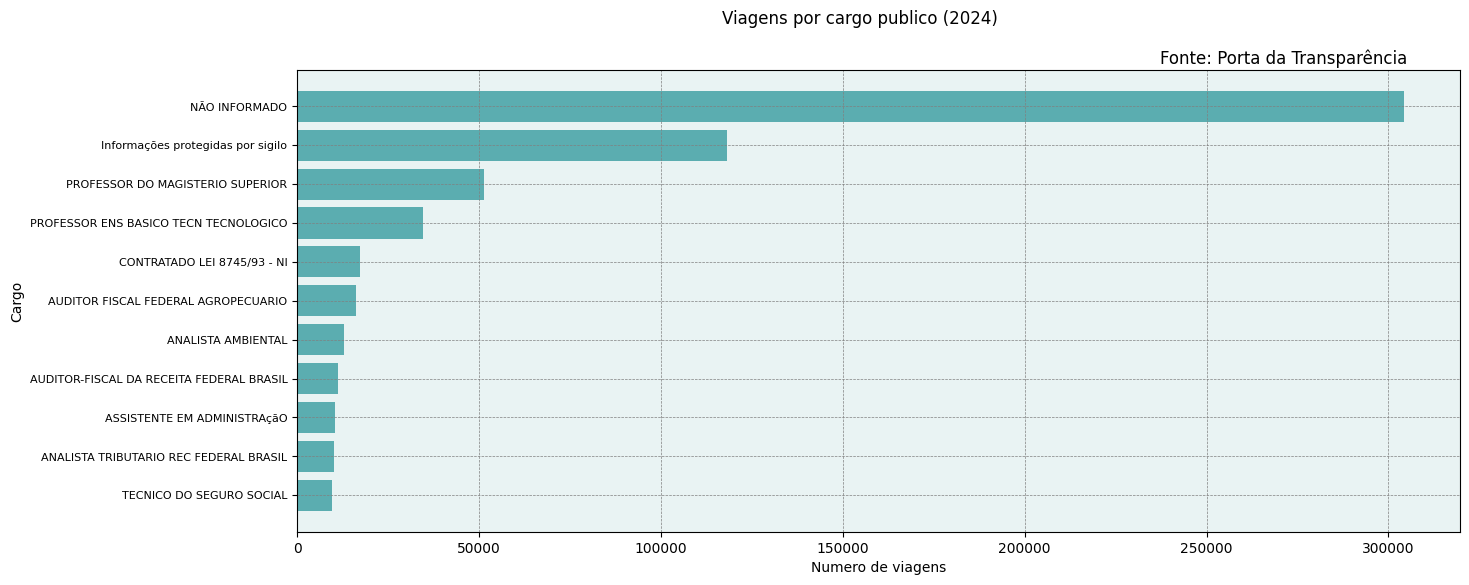

In [ ]:
import matplotlib.pyplot as plt

caminho_figura = '/content/drive/MyDrive/Analise_De_Dados/output/figura.png'
fig, ax = plt.subplots(figsize=(15, 6))
#Cargos e cor das barras
ax.barh(df_final['Cargo'], df_final['n_viagens'], color='#5BADB0')
ax.invert_yaxis()
ax.set_ylabel('Cargo')
#Cor de fundo
ax.set_facecolor('#E9F3F3')



fig.suptitle('Viagens por cargo publico (2024)')
#Titulo e posição do texto
plt.figtext(0.70, 0.89, 'Fonte: Porta da Transparência', fontsize=12)

plt.grid(color = 'gray', linestyle= '--', linewidth=0.5)
plt.yticks(fontsize=8)

plt.xlabel('Numero de viagens')

plt.savefig(caminho_figura, bbox_inches='tight')
